---
# Consistencia Semántica de Tópicos con Embeddings
## Python + Sentence Embeddings
---

En **5b** le pedimos a un LLM que **leyera y calificara** la coherencia de cada tópico en una escala de 1 a 5. Encontramos una limitación real: el modelo tiende a concentrar casi todos sus puntajes en 5, lo que deja poco margen para distinguir entre modelos con $k=12$, $k=20$ y $k=25$.

En este notebook usamos un enfoque distinto y **puramente matemático**: en vez de pedirle a un LLM que *opine* sobre la coherencia, medimos la **distancia real entre las palabras de un tópico en un espacio vectorial** (*embeddings*).

La idea central:

> Si las palabras de un tópico son **semánticamente cercanas** en el espacio de embeddings (alta similitud coseno promedio entre ellas), el tópico es coherente. Si están dispersas (baja similitud), el tópico mezcla conceptos poco relacionados.

A diferencia de pedirle una nota a un LLM, este método produce un número **continuo** (no un entero de 1 a 5), lo que debería darnos una comparación entre valores de $k$ mucho más informativa.

> 🖥️ **Sobre el hardware:** este notebook es mucho más liviano que 5b. El modelo de embeddings que usamos (~110M parámetros) es unas 30 veces más pequeño que el LLM de 5b, y calcular una similitud coseno es prácticamente instantáneo. Corre en pocos segundos incluso en **CPU** — no necesitas GPU, aunque igual la usaremos automáticamente si está disponible.

## 🎯 Objetivos de aprendizaje

- Entender la diferencia entre pedirle a un LLM que **evalúe** coherencia (5b) y **medirla matemáticamente** con embeddings (este notebook).
- Generar embeddings de palabras con un modelo de Hugging Face (`sentence-transformers`).
- Calcular la similitud coseno promedio entre las palabras de un tópico como una métrica continua de coherencia.
- Comparar esta métrica entre $k=12$, $k=20$ y $k=25$, y contrastar los resultados con los de 5b.

# ¿Qué son los Embeddings?

Hasta este punto del curso hemos representado los documentos mediante una **Document-Feature Matrix (DFM)**, en la que cada documento se describe por las palabras que contiene y su frecuencia de aparición. Sobre esta representación hemos construido modelos como **Bag of Words**, **TF-IDF** y **LDA**.

Aunque este enfoque ha demostrado ser muy útil, presenta una limitación importante: **no captura el significado de las palabras**. Para estos modelos, dos palabras distintas son simplemente dos términos diferentes, incluso si tienen un significado muy similar.

Los **embeddings** surgieron para resolver este problema. En lugar de representar una palabra mediante una columna de la DFM o una frecuencia de aparición, la representan mediante un **vector numérico denso** que captura información sobre su significado. Como consecuencia, palabras que aparecen en contextos similares tienden a tener representaciones numéricas similares.

Este cambio permitió pasar de una representación basada en frecuencias de palabras a una representación basada en **relaciones semánticas**, constituyendo uno de los avances más importantes en el desarrollo del Procesamiento de Lenguaje Natural moderno.

## 🔄 De la DFM a los Embeddings

📊 **Representación clásica:**  
La **Document-Feature Matrix (DFM)** representa cada documento mediante las palabras que contiene y la frecuencia con la que aparecen. Esta representación constituye la base de modelos como **Bag of Words**, **TF-IDF** y **LDA**.

🧠 **Representación semántica:**  
Los **embeddings** adoptan un enfoque diferente. En lugar de representar el texto mediante frecuencias de palabras, representan palabras, oraciones o documentos mediante **vectores densos** que capturan información sobre su significado.

📌 **Cambio de paradigma:**  
La siguiente figura resume esta diferencia fundamental entre ambas formas de representar el texto.

![DFM_to_Embeddings](../images/DFM_to_Embeddings.png)

## 📐 Representaciones *Sparse* y *Dense*

La principal diferencia entre la **Document-Feature Matrix (DFM)** y los **embeddings** radica en la forma en que representan la información.

📊 **Representación *Sparse* (dispersa):**  
En una DFM, cada palabra del vocabulario corresponde a una columna distinta. Como cada documento contiene solo una pequeña fracción de todas las palabras posibles, la mayoría de los valores de la matriz son **0**. Por esta razón, este tipo de representación se denomina *sparse* (dispersa).

🧠 **Representación *Dense* (densa):**  
Los embeddings representan palabras, oraciones o documentos mediante un número mucho menor de valores numéricos. En este caso, prácticamente todos los elementos del vector contienen información útil, por lo que la representación se considera *dense* (densa).

📌 **Idea clave:**  
Mientras que una representación *sparse* describe **qué palabras aparecen** en un documento, una representación *dense* busca capturar **el significado del texto** mediante un conjunto compacto de características numéricas.

![Sparse_Dense](../images/Sparse_Dense.png)

## 🌍 El Espacio Semántico

Hasta ahora hemos visto que los embeddings representan palabras, oraciones o documentos mediante **vectores densos**. Sin embargo, la verdadera utilidad de estos vectores radica en que pueden compararse entre sí.

📍 **Proximidad semántica:**  
En el espacio de embeddings, elementos con significados similares tienden a ubicarse cerca unos de otros. Por ejemplo, palabras como *perro* y *cachorro* tendrán representaciones muy próximas, mientras que palabras sin relación, como *automóvil* y *plátano*, aparecerán mucho más alejadas.

📏 **Medida de similitud:**  
La distancia o el ángulo entre dos vectores permite cuantificar cuán similares son sus significados. Esta propiedad constituye la base de numerosas aplicaciones modernas, como la búsqueda semántica, los sistemas de recomendación, la clasificación automática de textos y el modelamiento de temas.

📌 **Idea clave:**  
Los embeddings transforman el lenguaje en un espacio matemático donde la cercanía entre vectores refleja la similitud semántica entre palabras, oraciones o documentos.

![Semantic_Space](../images/Semantic_Space.png)

## 🧮 El Vector de Embeddings

Hasta ahora hemos visto que los embeddings representan palabras, oraciones o documentos mediante **vectores numéricos**. Pero, ¿qué representan realmente esos números?

📐 **Cada embedding es un vector:**  
Cada palabra, oración o documento se representa mediante un único vector compuesto por un conjunto de valores numéricos denominados **dimensiones**. Cada dimensión captura una pequeña parte de la información aprendida por el modelo durante el entrenamiento. Aunque, por sí sola, una dimensión no suele tener una interpretación directa, el conjunto de todas ellas permite representar el significado del texto.

📊 **Número de dimensiones:**  
No todos los modelos utilizan vectores del mismo tamaño. Por ejemplo, algunos modelos generan embeddings de **384 dimensiones**, mientras que otros utilizan **768** o incluso **1024 dimensiones**. En general, un mayor número de dimensiones permite representar relaciones semánticas más complejas, aunque también aumenta el costo computacional.

📌 **Idea clave:**  
El significado de una palabra no está contenido en un único número, sino en la combinación de **todas las dimensiones** de su vector de embedding.

![Embedding Vector](../images/Embedding_Vector.png)

## 🧠 ¿Cómo aprenden los modelos estos vectores?

Hasta ahora hemos visto que cada palabra, oración o documento puede representarse mediante un vector numérico. Pero surge una pregunta fundamental:

> **¿Cómo adquieren significado esos números?**

🎲 **Inicialización aleatoria:**  
Al comienzo del entrenamiento, los vectores de embedding se inicializan con valores prácticamente aleatorios. En esta etapa, palabras como *perro*, *gato* y *automóvil* no presentan ninguna relación semántica; sus vectores son simplemente conjuntos de números sin significado.

🧠 **Aprendizaje mediante redes neuronales:**  
Durante el entrenamiento, una red neuronal procesa millones de ejemplos de texto e intenta realizar una tarea, como predecir la siguiente palabra o determinar si dos oraciones tienen un significado similar. Después de cada predicción, el modelo calcula el error cometido mediante una **función de pérdida (Loss Function)**.

📉 **Gradient Descent:**  
A partir de este error, el algoritmo **Gradient Descent** ajusta ligeramente los valores de los embeddings y del resto de los parámetros de la red para reducir la pérdida. Este proceso se repite millones de veces, haciendo que palabras utilizadas en contextos similares terminen con representaciones también similares.

⏹️ **¿Cuándo termina el entrenamiento?**  
El proceso continúa hasta que la función de pérdida deja de mejorar significativamente, se alcanza un número máximo de iteraciones (*epochs*) o el rendimiento sobre un conjunto de validación deja de aumentar.

📌 **Idea clave:**  
Los embeddings no contienen significado desde el inicio. Su capacidad para representar relaciones semánticas surge gradualmente mediante un proceso iterativo de aprendizaje.

El objetivo del entrenamiento consiste en minimizar una función de pérdida,

$$
L(\theta),
$$

que mide el error cometido por el modelo.

En cada iteración, los parámetros del modelo (incluyendo los embeddings) se actualizan mediante la regla

$$
\theta_{t+1}
=
\theta_t
-
\eta
\nabla_{\theta}L(\theta_t),
$$

donde:

- $L(\theta)$ es la función de pérdida.
- $\nabla_{\theta}L(\theta)$ es el gradiente de la pérdida.
- $\eta$ es la **tasa de aprendizaje (*learning rate*)**, que controla el tamaño de cada actualización.

## 🤖 ¿Cómo se generan los embeddings?

Hasta ahora hemos tratado los embeddings como si simplemente existieran. Sin embargo, surge una pregunta natural:

> **¿Quién calcula estos vectores?**

En la actualidad, la mayoría de los embeddings utilizados en Procesamiento de Lenguaje Natural son generados por **modelos Transformer** entrenados sobre enormes colecciones de texto. Durante el entrenamiento, estos modelos aprenden a representar palabras, oraciones e incluso documentos mediante vectores que preservan relaciones semánticas.

📚 **Modelos preentrenados:**  
En lugar de entrenar un modelo desde cero, normalmente utilizamos modelos ya entrenados (*pre-trained models*), capaces de generar embeddings de alta calidad para nuevos textos.

🚀 **Sentence Transformers:**  
Los **Sentence Transformers** constituyen una familia de modelos diseñada específicamente para producir embeddings de oraciones y documentos completos. Estos modelos generan representaciones que pueden compararse directamente mediante medidas de similitud, facilitando tareas como búsqueda semántica, clasificación de textos y modelamiento de temas.

📌 **En este notebook:**  
Utilizaremos un modelo **Sentence Transformer** denominado **MPNet**, uno de los modelos más utilizados por su excelente equilibrio entre precisión y velocidad.

![Sentence_Transformers](../images/Sentence_Transformers.png)

## 🧮 ¿Qué modelo de embeddings usamos?

Usaremos **`sentence-transformers/all-mpnet-base-v2`** (MPNet).

Es una alternativa a modelos más grandes como `BAAI/bge-large-en-v1.5` (BGE), con ventajas prácticas para este notebook:

- **Liviano (~420 MB, 110M parámetros)** frente a BGE-large (~1.3 GB, 335M parámetros) — se descarga y carga notablemente más rápido, igual que preferimos un modelo más chico en 5b.
- **No requiere *prompts* especiales.** BGE recomienda anteponer frases específicas como `"Represent this sentence for searching relevant passages: "` para obtener su mejor rendimiento en tareas de *búsqueda*; nuestra tarea (medir qué tan cerca están las palabras de un mismo tópico) no es una tarea de búsqueda, y MPNet está entrenado de forma general para similitud semántica sin necesitar ese tipo de ajuste.
- **Ampliamente probado**: es uno de los modelos de `sentence-transformers` más usados y no tiene restricciones de acceso.

BGE suele obtener puntajes ligeramente más altos en benchmarks de *retrieval* (búsqueda de documentos), pero para medir similitud semántica general entre palabras — que es justamente lo que necesitamos — la diferencia práctica es mínima.

> 📌 El nombre del modelo está aislado en una sola variable (`MODEL_NAME`). Si quieres comparar con BGE, cambia `MODEL_NAME` a `"BAAI/bge-large-en-v1.5"` — el resto del notebook funciona igual.

## 🧩 ¿Por qué utilizaremos MPNet?

Existen numerosos modelos capaces de generar embeddings, como **BERT**, **RoBERTa**, **MiniLM**, **DistilBERT**, **E5** y **MPNet**. Todos ellos pertenecen a la familia de los **Transformers**, pero difieren en su arquitectura, tamaño, velocidad y calidad de las representaciones que producen.

⚖️ **Equilibrio entre precisión y eficiencia:**  
Entre estos modelos, **MPNet** destaca por ofrecer un excelente equilibrio entre calidad de los embeddings y velocidad de procesamiento. Esto lo convierte en una de las opciones más utilizadas para tareas como búsqueda semántica, clasificación de textos y modelamiento de temas.

📊 **¿Por qué es importante?**  
Modelos como **BERTopic** requieren comparar miles de documentos entre sí. Por ello, es fundamental utilizar embeddings que representen adecuadamente el significado del texto sin sacrificar demasiado rendimiento computacional.

📌 **En este notebook:**  
Utilizaremos el modelo **all-mpnet-base-v2**, uno de los modelos más populares de la biblioteca **Sentence Transformers**, ampliamente empleado en investigación y aplicaciones de Procesamiento de Lenguaje Natural.

## 📦 Instalación de las librerías necesarias

In [13]:
!pip install -q sentence-transformers pandas numpy matplotlib scikit-learn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

## 🧠 Cargar el modelo de embeddings

Igual que en 5b, detectamos automáticamente el hardware disponible. A diferencia del LLM de 5b, este modelo es lo suficientemente liviano como para que la diferencia entre GPU y CPU sea de segundos, no de minutos.

In [15]:
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Usando dispositivo: {device}")
modelo_embeddings = SentenceTransformer(MODEL_NAME, device=device)

Usando dispositivo: mps


## 📂 Cargar los tópicos exportados desde R (Unidad 5a)

Los tres archivos deben estar en el mismo directorio de trabajo que este notebook.

> 📌 **Si estás en Google Colab:** sube los tres archivos (`lda_topterms_k12.csv`, `lda_topterms_k20.csv`, `lda_topterms_k25.csv`) usando el panel de archivos (ícono de 📁 en la barra lateral izquierda) antes de ejecutar la siguiente celda — ver la nota detallada en 5b si no lo has hecho antes.

In [16]:
topterms_12 = pd.read_csv("lda_topterms_k12.csv")
topterms_20 = pd.read_csv("lda_topterms_k20.csv")
topterms_25 = pd.read_csv("lda_topterms_k25.csv")

topterms_12.head()

,topic,term,beta,k
0,1,action,0.022739,12
1,1,jackie,0.011834,12
2,1,plot,0.006915,12
3,1,crime,0.006590,12
4,1,cop,0.006266,12


## ✂️ Palabras clave por tópico

La misma función utilizada en 5b: obtiene las $n$ palabras con mayor probabilidad ($\beta$) de un tópico.

In [17]:
def get_topic_words(df, topic_id, n=15):
    palabras = (
        df[df["topic"] == topic_id]
        .sort_values("beta", ascending=False)
        .head(n)["term"]
        .tolist()
    )
    return palabras

get_topic_words(topterms_20, topic_id=1)

['action',
 'jackie',
 'chan',
 'van',
 'fight',
 'plot',
 'hong',
 'kong',
 'bond',
 'chinese',
 'martial',
 'arts',
 'films',
 'damme',
 'blade']

## 📐 De palabras a un puntaje de coherencia

Para un tópico con $n$ palabras, el procedimiento es:

1. Generar un embedding (vector de 768 dimensiones) para cada una de las $n$ palabras.
2. Calcular la **similitud coseno** entre cada par de palabras — esto produce una matriz de $n \times n$ similitudes.
3. Promediar todas las similitudes, **excluyendo la diagonal** (la similitud de una palabra consigo misma siempre es 1, y no aporta información).

El resultado es un número entre -1 y 1 (en la práctica, casi siempre entre 0 y 1 para palabras en inglés): mientras más alto, más cercanas están las palabras entre sí en el espacio semántico, y por lo tanto, más coherente es el tópico.

> 🧠 A diferencia del puntaje 1-5 de un LLM, este es un número **continuo** — dos tópicos pueden tener 0.31 y 0.34 de similitud promedio, una diferencia real que un LLM forzado a elegir un entero entre 1 y 5 probablemente redondearía al mismo puntaje.

In [18]:
def coherencia_por_embeddings(palabras):
    embeddings = modelo_embeddings.encode(palabras)
    matriz_similitud = cosine_similarity(embeddings)

    # excluimos la diagonal (similitud de cada palabra consigo misma = 1)
    n = len(palabras)
    mascara = ~np.eye(n, dtype=bool)
    similitudes = matriz_similitud[mascara]

    return similitudes.mean()


# ejemplo con un solo tópico
palabras_ejemplo = get_topic_words(topterms_20, topic_id=1)
coherencia_por_embeddings(palabras_ejemplo)

np.float32(0.25181532)

## 🔁 Aplicar a todos los tópicos de un modelo

A diferencia de 5b, aquí no hay llamadas a un LLM ni *prompts* que parsear — solo embeddings y álgebra lineal, por lo que esta celda debería ejecutarse en segundos para los 57 tópicos combinados.

In [19]:
def evaluate_model_topics_embeddings(df, k, n_words=15):
    resultados = []
    for topic_id in sorted(df["topic"].unique()):
        palabras = get_topic_words(df, topic_id, n=n_words)
        coherencia = coherencia_por_embeddings(palabras)
        resultados.append({
            "k": k,
            "topic": topic_id,
            "coherencia_embeddings": coherencia,
            "palabras": ", ".join(palabras),
        })
    return pd.DataFrame(resultados)

In [20]:
resultados_12 = evaluate_model_topics_embeddings(topterms_12, k=12)
resultados_20 = evaluate_model_topics_embeddings(topterms_20, k=20)
resultados_25 = evaluate_model_topics_embeddings(topterms_25, k=25)

resultados_todos = pd.concat([resultados_12, resultados_20, resultados_25], ignore_index=True)
resultados_todos

,k,topic,coherencia_embeddings,palabras
0,12,1,0.270907,"action, jackie, plot, crime, cop, chan, s, mov..."
1,12,2,0.262084,"wild, sex, girls, party, scene, harry, drug, h..."
2,12,3,0.306414,"love, life, family, romantic, comedy, woman, t..."
3,12,4,0.297964,"alien, ship, aliens, effects, planet, action, ..."
4,12,5,0.285985,"batman, vampire, wife, robin, book, arnold, va..."
5,12,6,0.233045,"scream, horror, school, killer, high, summer, ..."
6,12,7,0.243538,"effects, star_wars, special, movie, space, sci..."
7,12,8,0.255596,"disney, story, animated, voice, animation, tar..."
8,12,9,0.271456,"war, movie, political, men, american, black, w..."
9,12,10,0.229760,"film, one, story, like, character, characters,..."


## 📊 Comparar la coherencia promedio por valor de $k$

In [21]:
coherencia_promedio = resultados_todos.groupby("k")["coherencia_embeddings"].mean()
coherencia_promedio

k
12    0.264777
20    0.258411
25    0.263814
Name: coherencia_embeddings, dtype: float32

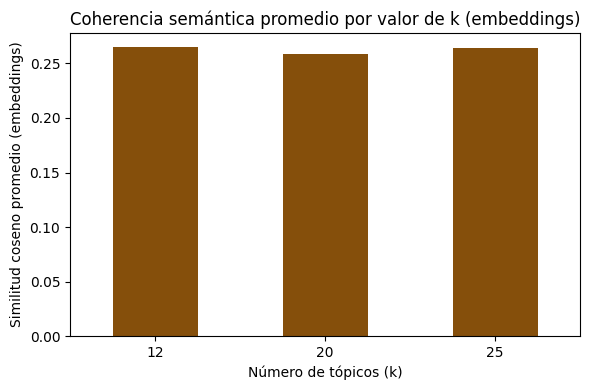

In [22]:
plt.figure(figsize=(6, 4))
coherencia_promedio.plot(kind="bar", color=["#854f0b", "#854f0b", "#854f0b"])
plt.ylabel("Similitud coseno promedio (embeddings)")
plt.xlabel("Número de tópicos (k)")
plt.title("Coherencia semántica promedio por valor de k (embeddings)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## ⚖️ Comparación con el enfoque LLM (5b)

En 5b encontramos que el LLM concentraba casi todos sus puntajes en 5, dejando poco margen para distinguir entre modelos. Vale la pena revisar si este método de embeddings **sí** logra distinguirlos.

Ejecuta esta celda y observa:

- ¿La `coherencia_embeddings` varía más entre tópicos que el puntaje 1-5 del LLM en 5b?
- ¿La tendencia entre $k=12$, $k=20$ y $k=25$ apunta en la misma dirección que en 5b, o difiere?

In [23]:
resultados_todos.groupby("k")["coherencia_embeddings"].describe()

,count,mean,std,min,25%,50%,75%,max
k,,,,,,,,
12,12.0,0.264777,0.024104,0.229760,0.248450,0.266289,0.275088,0.306414
20,20.0,0.258411,0.027549,0.210342,0.242958,0.249190,0.279201,0.314308
25,25.0,0.263814,0.030918,0.207301,0.254757,0.261529,0.285676,0.338389


### 🔍 Lo que muestran los resultados

En una ejecución real, el promedio de `coherencia_embeddings` por valor de $k$ fue:

| $k$ | Coherencia promedio (embeddings) |
|---|---|
| 12 | ≈ 0.265 |
| 20 | ≈ 0.258 |
| 25 | ≈ 0.264 |

La respuesta a las dos preguntas de arriba es, sorprendentemente, **mixta**:

- **Sí, hay más variación entre tópicos individuales.** Los tópicos van de ~0.207 a ~0.338 — un rango real, muy distinto a los puntajes del LLM en 5b, que se concentraban casi todos en 5.
- **Pero no, la tendencia entre valores de $k$ no es más clara — es casi plana.** Las tres medias están a menos de 0.007 entre sí, sin una dirección evidente. En 5b, en cambio, el LLM mostraba una **leve tendencia decreciente** (5.0 → 4.9 → 4.68) a medida que aumentaba $k$, a pesar de tener puntajes mucho más comprimidos dentro de cada modelo.

Esto es un hallazgo interesante en sí mismo: **más granularidad dentro de un modelo no implica necesariamente una señal más clara entre modelos**. El promedio simple de similitud coseno entre las 15 palabras principales parece capturar qué tan "compacto" es un tópico en general, pero no necesariamente cómo cambia esa compacidad a medida que se agregan más tópicos en este rango ($k=12$ a $25$). Una métrica más específica — por ejemplo, ponderada por $\beta$, o comparada contra la similitud promedio de palabras aleatorias del corpus como referencia — probablemente sería necesaria para detectar diferencias reales entre valores de $k$.

> 📌 **Idea clave:** ningún método es automáticamente "mejor" por ser más granular o más matemático. Los embeddings resolvieron el problema de discriminación *dentro* de un modelo, pero no el de comparación *entre* modelos — mientras que el LLM, pese a su escala comprimida, sí ofrecía una tendencia (débil) entre valores de $k$. Elegir el método correcto depende de qué pregunta te estás haciendo.

## ✅ Cierre

Este notebook ofrece una **tercera perspectiva** sobre la calidad de los modelos de tópicos, complementando las dos anteriores:

- **R / Quanteda + topicmodels (5a)**: métricas estadísticas del ajuste del modelo (perplexity, elbow method) — objetivas, pero no dicen nada sobre si un tópico "tiene sentido" para un humano.
- **Python + LLM (5b)**: un LLM lee las palabras y opina sobre su coherencia — captura matices semánticos que una métrica puramente numérica no puede, pero su escala 1-5 resultó poco discriminante.
- **Python + Embeddings (este notebook)**: mide la distancia matemática real entre las palabras — produce un número continuo, más fácil de comparar entre modelos, pero es una medida más "mecánica": no entiende *por qué* un grupo de palabras tiene sentido temático, solo qué tan cerca están en un espacio vectorial entrenado de forma general.

> 📌 **Idea clave:** ningún método es suficiente por sí solo. Las métricas estadísticas, el juicio cualitativo de un LLM y la distancia matemática de los embeddings son **tres fuentes de evidencia complementarias** — y comparar sus conclusiones (¿coinciden en cuál $k$ es mejor?, ¿dónde difieren y por qué?) es en sí mismo un ejercicio de análisis crítico central en este curso.